# Machine Learning Pipeline: Anxiety Prediction

This notebook builds and tests three predictive models to classify **high anxiety levels** based on the MXMH survey data.

## How to Test the Data

Run each cell **in order** from top to bottom (Shift+Enter). The pipeline follows these steps:

1. **Load** the cleaned data and define the target variable
2. **Preprocess** features (scale numeric, encode categorical)
3. **Split** data into train (80%) and test (20%) sets
4. **Train** three models with hyperparameter tuning
5. **Evaluate** each model on the held-out test set
6. **Compare** models side-by-side
7. **Analyze** feature importance

## Step 1: Import Libraries

We import scikit-learn for model building, xgboost for gradient boosting, and pandas/numpy for data handling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    precision_recall_curve
)

from xgboost import XGBClassifier

print("All libraries loaded successfully!")

All libraries loaded successfully!


## Step 2: Load Data and Define Target

We load the cleaned CSV and define `high_anxiety` as our binary target (1 = anxiety score >= 7).

**Important:** We drop the raw mental health scores (`anxiety`, `depression`, `insomnia`, `ocd`) from the features to avoid **data leakage** - we don't want the model to "cheat" by using the answer to predict itself.

In [3]:
# Load cleaned data
df = pd.read_csv("mxmh_clean.csv")

# Define target (classification)
target = "high_anxiety"
if target not in df.columns:
    raise ValueError(f"{target} not found. Run the cleaning script first.")

# Avoid leakage: drop all mental health score columns from features
leak_cols = ["anxiety", "depression", "insomnia", "ocd", target]
leak_cols = [c for c in leak_cols if c in df.columns]

X = df.drop(columns=leak_cols)
y = df[target].astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Features shape: {X.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nTarget balance: {y.value_counts(normalize=True).round(3).to_dict()}")

Dataset shape: (735, 32)
Features shape: (735, 27)

Target distribution:
high_anxiety
0    375
1    360
Name: count, dtype: int64

Target balance: {0: 0.51, 1: 0.49}


## Step 3: Preprocessing Pipelines

We create two preprocessing pipelines:
- **Linear models** (Logistic Regression): need **scaling** for numeric features
- **Tree-based models** (Random Forest, XGBoost): only need imputation, not scaling

In [4]:
# Identify column types
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "bool"]).columns.tolist()

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

# Preprocessing for Linear Models
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_linear = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Preprocessing for Tree Models
numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("\nPreprocessing pipelines ready!")

Numeric features (24): ['age', 'hours_per_day', 'while_working', 'instrumentalist', 'composer', 'exploratory', 'foreign_languages', 'bpm', 'frequency_classical', 'frequency_country', 'frequency_edm', 'frequency_folk', 'frequency_gospel', 'frequency_hip_hop', 'frequency_jazz', 'frequency_k_pop', 'frequency_latin', 'frequency_lofi', 'frequency_metal', 'frequency_pop', 'frequency_rb', 'frequency_rap', 'frequency_rock', 'frequency_video_game_music']
Categorical features (3): ['primary_streaming_service', 'fav_genre', 'music_effects']

Preprocessing pipelines ready!


## Step 4: Train-Test Split

We split the data **80/20** with stratification so both train and test sets have the same proportion of high vs low anxiety. The `random_state=42` ensures reproducibility.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")
print(f"\nTrain target distribution: {y_train.value_counts().to_dict()}")
print(f"Test target distribution:  {y_test.value_counts().to_dict()}")

Train set: 588 samples
Test set:  147 samples

Train target distribution: {0: 300, 1: 288}
Test target distribution:  {0: 75, 1: 72}


## Step 5: Model Training with Hyperparameter Tuning

We define three models and use **RandomizedSearchCV** with **5-fold stratified cross-validation** to find the best hyperparameters for each.

- **Logistic Regression**: Tunes the regularization strength `C`
- **Random Forest**: Tunes number of trees, depth, split criteria
- **XGBoost**: Tunes learning rate, depth, sampling parameters

This cell may take 1-2 minutes to run.

In [6]:
# Define models
log_clf = LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs")

rf_clf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

xgb_clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Create pipelines (preprocessing + model)
pipe_log = Pipeline(steps=[("prep", preprocess_linear), ("model", log_clf)])
pipe_rf = Pipeline(steps=[("prep", preprocess_tree), ("model", rf_clf)])
pipe_xgb = Pipeline(steps=[("prep", preprocess_tree), ("model", xgb_clf)])

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Hyperparameter grids
param_log = {
    "model__C": np.logspace(-3, 2, 20)
}

param_rf = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [5, 10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

param_xgb = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0],
    "model__min_child_weight": [1, 3, 5]
}

# Randomized search using Average Precision (good for imbalanced data)
search_log = RandomizedSearchCV(
    pipe_log, param_distributions=param_log,
    n_iter=20, scoring="average_precision",
    cv=cv, random_state=42, n_jobs=-1
)

search_rf = RandomizedSearchCV(
    pipe_rf, param_distributions=param_rf,
    n_iter=25, scoring="average_precision",
    cv=cv, random_state=42, n_jobs=-1
)

search_xgb = RandomizedSearchCV(
    pipe_xgb, param_distributions=param_xgb,
    n_iter=25, scoring="average_precision",
    cv=cv, random_state=42, n_jobs=-1
)

# Train all models
print("Tuning Logistic Regression...")
search_log.fit(X_train, y_train)

print("Tuning Random Forest...")
search_rf.fit(X_train, y_train)

print("Tuning XGBoost...")
search_xgb.fit(X_train, y_train)

print("\n--- Best Hyperparameters ---")
print("Logistic Regression:", search_log.best_params_)
print("Random Forest:", search_rf.best_params_)
print("XGBoost:", search_xgb.best_params_)

print("\n--- Cross-Validation Average Precision ---")
print(f"Logistic Regression: {search_log.best_score_:.4f}")
print(f"Random Forest:       {search_rf.best_score_:.4f}")
print(f"XGBoost:             {search_xgb.best_score_:.4f}")

Tuning Logistic Regression...
Tuning Random Forest...
Tuning XGBoost...

--- Best Hyperparameters ---
Logistic Regression: {'model__C': np.float64(0.42813323987193913)}
Random Forest: {'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 5}
XGBoost: {'model__subsample': 0.85, 'model__n_estimators': 200, 'model__min_child_weight': 5, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__colsample_bytree': 1.0}

--- Cross-Validation Average Precision ---
Logistic Regression: 0.5313
Random Forest:       0.5550
XGBoost:             0.5416


## Step 6: Evaluate on Test Set

Now we evaluate each tuned model on the **held-out test set** (data the model has never seen). This gives us an unbiased estimate of real-world performance.

**Metrics explained:**
- **Average Precision**: Area under the precision-recall curve (best for imbalanced data)
- **ROC AUC**: Area under the ROC curve
- **Precision**: Of all predicted "high anxiety", how many actually are?
- **Recall**: Of all actual "high anxiety" cases, how many did we find?
- **F1 Score**: Harmonic mean of precision and recall

In [7]:
def eval_model(model, X_te, y_te, name="model"):
    proba = model.predict_proba(X_te)[:, 1]
    preds = (proba >= 0.5).astype(int)

    ap = average_precision_score(y_te, proba)
    auc = roc_auc_score(y_te, proba)
    prec = precision_score(y_te, preds, zero_division=0)
    rec = recall_score(y_te, preds, zero_division=0)
    f1 = f1_score(y_te, preds, zero_division=0)
    cm = confusion_matrix(y_te, preds)

    print(f"\n{name}")
    print(f"  Average Precision: {ap:.4f}")
    print(f"  ROC AUC:           {auc:.4f}")
    print(f"  Precision:         {prec:.4f}")
    print(f"  Recall:            {rec:.4f}")
    print(f"  F1:                {f1:.4f}")
    print(f"  Confusion Matrix:\n{cm}")
    print(f"\n{classification_report(y_te, preds, zero_division=0)}")

    return {"model": name, "ap": ap, "roc_auc": auc, "precision": prec, "recall": rec, "f1": f1}

best_log = search_log.best_estimator_
best_rf = search_rf.best_estimator_
best_xgb = search_xgb.best_estimator_

results = []
results.append(eval_model(best_log, X_test, y_test, "Logistic Regression"))
results.append(eval_model(best_rf, X_test, y_test, "Random Forest"))
results.append(eval_model(best_xgb, X_test, y_test, "XGBoost"))

results_df = pd.DataFrame(results)
results_df


Logistic Regression
  Average Precision: 0.6128
  ROC AUC:           0.6333
  Precision:         0.5753
  Recall:            0.5833
  F1:                0.5793
  Confusion Matrix:
[[44 31]
 [30 42]]

              precision    recall  f1-score   support

           0       0.59      0.59      0.59        75
           1       0.58      0.58      0.58        72

    accuracy                           0.59       147
   macro avg       0.58      0.58      0.58       147
weighted avg       0.59      0.59      0.59       147


Random Forest
  Average Precision: 0.6406
  ROC AUC:           0.6446
  Precision:         0.5600
  Recall:            0.5833
  F1:                0.5714
  Confusion Matrix:
[[42 33]
 [30 42]]

              precision    recall  f1-score   support

           0       0.58      0.56      0.57        75
           1       0.56      0.58      0.57        72

    accuracy                           0.57       147
   macro avg       0.57      0.57      0.57       147
weigh

,model,ap,roc_auc,precision,recall,f1
0,Logistic Regression,0.612787,0.633333,0.575342,0.583333,0.579310
1,Random Forest,0.640631,0.644630,0.560000,0.583333,0.571429
2,XGBoost,0.652933,0.638519,0.575342,0.583333,0.579310


## Step 7: Model Comparison Visualization

Bar charts comparing all models across key metrics.

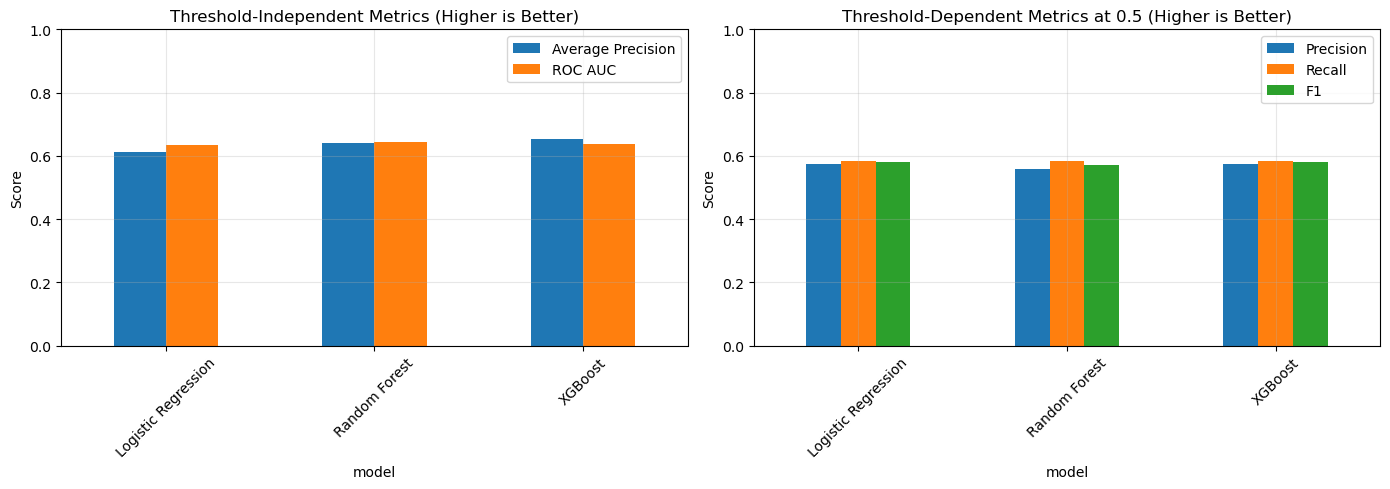

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Average Precision and ROC AUC
metrics_1 = results_df[['model', 'ap', 'roc_auc']].set_index('model')
metrics_1.plot(kind='bar', ax=axes[0], rot=45)
axes[0].set_title('Threshold-Independent Metrics (Higher is Better)')
axes[0].set_ylabel('Score')
axes[0].legend(['Average Precision', 'ROC AUC'])
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3)

# Plot 2: Precision, Recall, F1
metrics_2 = results_df[['model', 'precision', 'recall', 'f1']].set_index('model')
metrics_2.plot(kind='bar', ax=axes[1], rot=45)
axes[1].set_title('Threshold-Dependent Metrics at 0.5 (Higher is Better)')
axes[1].set_ylabel('Score')
axes[1].legend(['Precision', 'Recall', 'F1'])
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 8: Precision-Recall Curves

These curves show how precision and recall trade off at every possible decision threshold. Useful for choosing the best threshold for your use case.

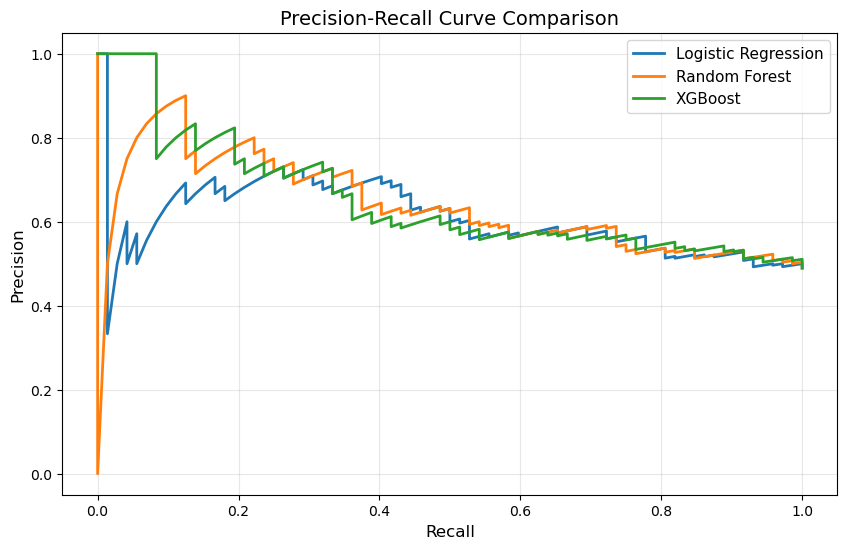

In [9]:
def plot_pr_curve(model, X_te, y_te, label):
    probs = model.predict_proba(X_te)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_te, probs)
    plt.plot(recall, precision, label=label, linewidth=2)

plt.figure(figsize=(10, 6))
plot_pr_curve(best_log, X_test, y_test, "Logistic Regression")
plot_pr_curve(best_rf, X_test, y_test, "Random Forest")
plot_pr_curve(best_xgb, X_test, y_test, "XGBoost")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve Comparison", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

## Step 9: Feature Importance (Random Forest)

This shows which features the Random Forest model considers most important for predicting high anxiety.

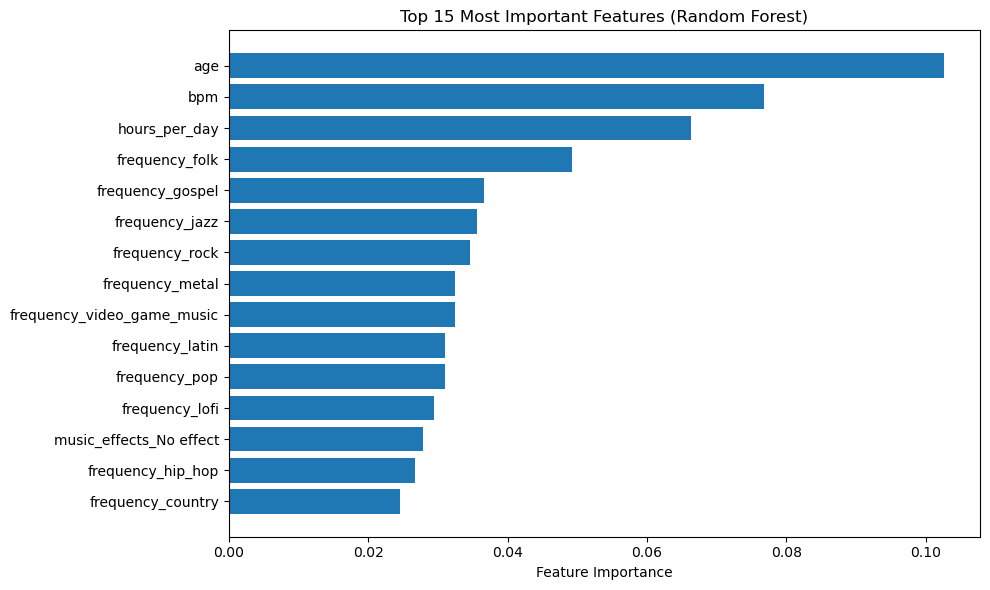

In [10]:
# Extract feature names after preprocessing
rf_model = best_rf.named_steps['model']
preprocessor = best_rf.named_steps['prep']

feature_names = []
feature_names.extend(numeric_features)
if len(categorical_features) > 0:
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
    feature_names.extend(cat_encoder.get_feature_names_out(categorical_features))

# Get feature importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # Top 15 features

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()